# Predicting H1N1 Flu Vaccine Uptake Using Machine Learning

# Introduction

The 2009 H1N1 influenza pandemic, commonly known as “swine flu,” was a global public health concern that led to widespread efforts to promote vaccination. H1N1 is a strain of the influenza virus that can spread rapidly through respiratory droplets, causing symptoms similar to seasonal flu but with the potential for severe complications in certain populations.

Vaccination is one of the most effective strategies for preventing influenza infection and reducing the spread of disease. However, not all individuals choose to receive the vaccine. Understanding the factors that influence vaccination decisions can help public health organizations design more effective vaccination campaigns.

This project analyzes survey data from the National 2009 H1N1 Flu Survey to explore how demographic characteristics, health behaviors, and attitudes toward vaccines influence whether individuals receive the H1N1 vaccine.

Using machine learning classification models, the project aims to predict whether an individual received the H1N1 vaccine. By identifying the factors that most strongly influence vaccination decisions, the analysis can provide insights that may help public health agencies improve vaccine outreach and communication strategies.

The project follows the standard data science workflow, including data exploration, data preparation, model development, and evaluation. Multiple classification models will be built and compared to determine which model best predicts vaccination uptake.



## Business Understanding

### Stakeholder

The primary stakeholders for this project are public health organizations and policymakers responsible for planning and implementing vaccination campaigns. These organizations aim to increase vaccination rates in order to reduce the spread of infectious diseases and protect vulnerable populations.

### Business Problem

During the 2009 H1N1 influenza pandemic, public health agencies promoted vaccination as a key strategy to control the spread of the virus. However, vaccination uptake varied widely among individuals. Understanding the factors that influence whether people choose to receive the H1N1 vaccine can help public health organizations design more effective outreach and education campaigns.

### Project Objective

The objective of this project is to develop a machine learning classification model that predicts whether an individual received the H1N1 vaccine based on their demographic characteristics, health status, preventive behaviors, and attitudes toward vaccines.

By identifying the variables most strongly associated with vaccination decisions, this analysis can provide insights that may help public health agencies improve targeted vaccination strategies and communication efforts.

the ojectives we want to achieve would be :

- Explore factors influencing vaccination decisions
- Build classification models to predict H1N1 vaccination
- Compare model performance
- Provide insights for public health stakeholders

## Models Used
- Logistic Regression
- Decision Tree
- Random Forest


## Data Understanding

The dataset used in this project comes from the National 2009 H1N1 Flu Survey, which collected information about individuals’ health behaviors, demographic characteristics, and attitudes toward the H1N1 influenza vaccine.

The dataset includes responses from thousands of individuals and contains a wide range of variables related to health status, vaccine perceptions, and preventive behaviors. These variables can help provide insight into the factors that influence vaccination decisions.

The data for this project is provided in two main files:

- **training_set_features.csv**: contains the predictor variables, including demographic information, health conditions, behavioral factors, and perceptions about the H1N1 virus and vaccine.
- **training_set_labels.csv**: contains the target variables indicating whether each respondent received the H1N1 vaccine and the seasonal flu vaccine.

Each record represents a single survey respondent. The datasets are linked using a unique identifier called **respondent_id**, which allows the features and labels to be merged into a single dataset for analysis.

In the following steps, the datasets will be loaded and merged, and initial exploratory analysis will be performed to understand the structure of the data, identify missing values, and examine the distribution of the target variable.

In [63]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

features = pd.read_csv("../data/raw/training_set_features.csv")
labels = pd.read_csv("../data/raw/training_set_labels.csv")

# Merge the Datasets

df = features.merge(labels, on="respondent_id")

df = features.merge(labels, on="respondent_id")

df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to understand the structure and characteristics of the dataset. This step helps identify patterns, detect missing values, and examine the distribution of key variables. Understanding the data at this stage is important because it guides the data preparation and modeling steps that follow.

In [55]:
df.shape 

(26707, 38)

In [56]:
df.columns

Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='object')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

#### Examine the target variable

In [58]:
# Examine the Target Variable h1n1_vaccine
df['h1n1_vaccine'].value_counts()


h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64

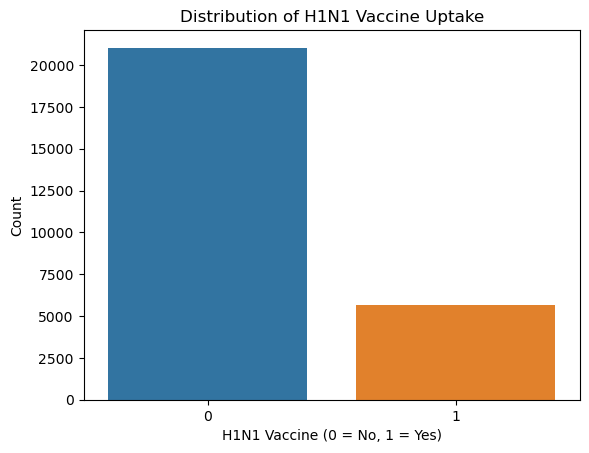

In [112]:
# visualize it:

sns.countplot(x='h1n1_vaccine', data=df)
plt.title("Distribution of H1N1 Vaccine Uptake")
plt.xlabel("H1N1 Vaccine (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.savefig("../images/plots/vaccine_distribution.png")
plt.show()

In [60]:
# Check Missing Values
df.isnull().sum().sort_values(ascending=False)


employment_occupation          13470
employment_industry            13330
health_insurance               12274
income_poverty                  4423
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
rent_or_own                     2042
employment_status               1463
marital_status                  1408
education                       1407
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
opinion_seas_sick_from_vacc      537
opinion_seas_risk                514
opinion_seas_vacc_effective      462
opinion_h1n1_sick_from_vacc      395
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
household_adults                 249
household_children               249
behavioral_avoidance             208
behavioral_touch_face            128
h1n1_knowledge                   116
h1n1_concern                      92
behavioral_large_gatherings       87
behavioral_outside_home           82
b

#### Explore vaccine attitudes

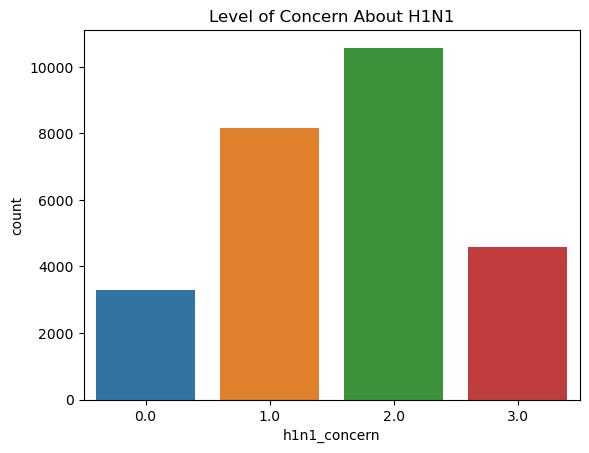

In [61]:
# Explore Vaccine Attitudes. Higher concern may be associated with higher vaccination rates.

sns.countplot(x='h1n1_concern', data=df)
plt.title("Level of Concern About H1N1")
plt.show()

The distribution of h1n1_concern shows that most repondents report moderate concern about h1n1. Fewer respondents report being completely unconcerned.

#### Doctor Recommendation vs Vaccination

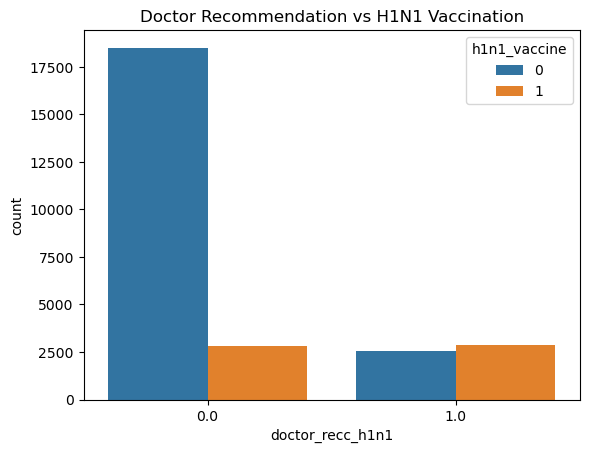

In [109]:
df['h1n1_vaccine'] = df['h1n1_vaccine'].astype(str)

sns.countplot(x='doctor_recc_h1n1', hue='h1n1_vaccine', data=df)

plt.title("Doctor Recommendation vs H1N1 Vaccination")

plt.savefig("../images/plots/doctor_recommendation.png")

plt.show()



Doctor recommendations strongly influenced vaccination behavior. people whose doctors reccomended the vaccine were much more likely to receive it compared to those who did not receive a reccomendation. 

#### Age Group and Vaccination

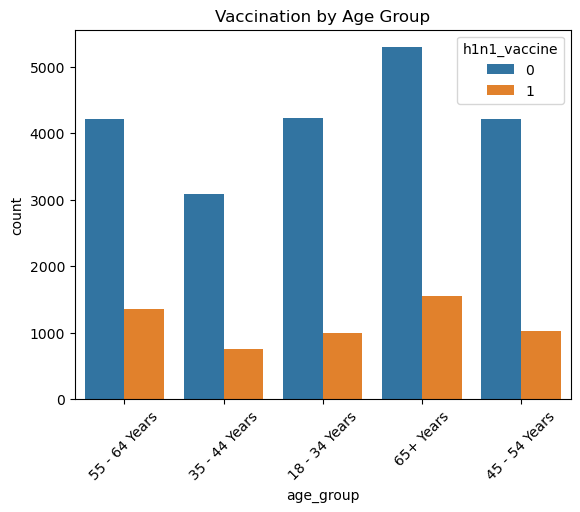

In [106]:
df['h1n1_vaccine'] = df['h1n1_vaccine'].astype(str)

sns.countplot(x='age_group', hue='h1n1_vaccine', data=df)

plt.xticks(rotation=45)

plt.title("Vaccination by Age Group")

plt.show()

Older individuals may be more likely to vaccinate. Younger individuals(18-44) appear less likely to receive H1N1 vaccine possibly due to lower perceived health risks.

#### Correlation Between Variables

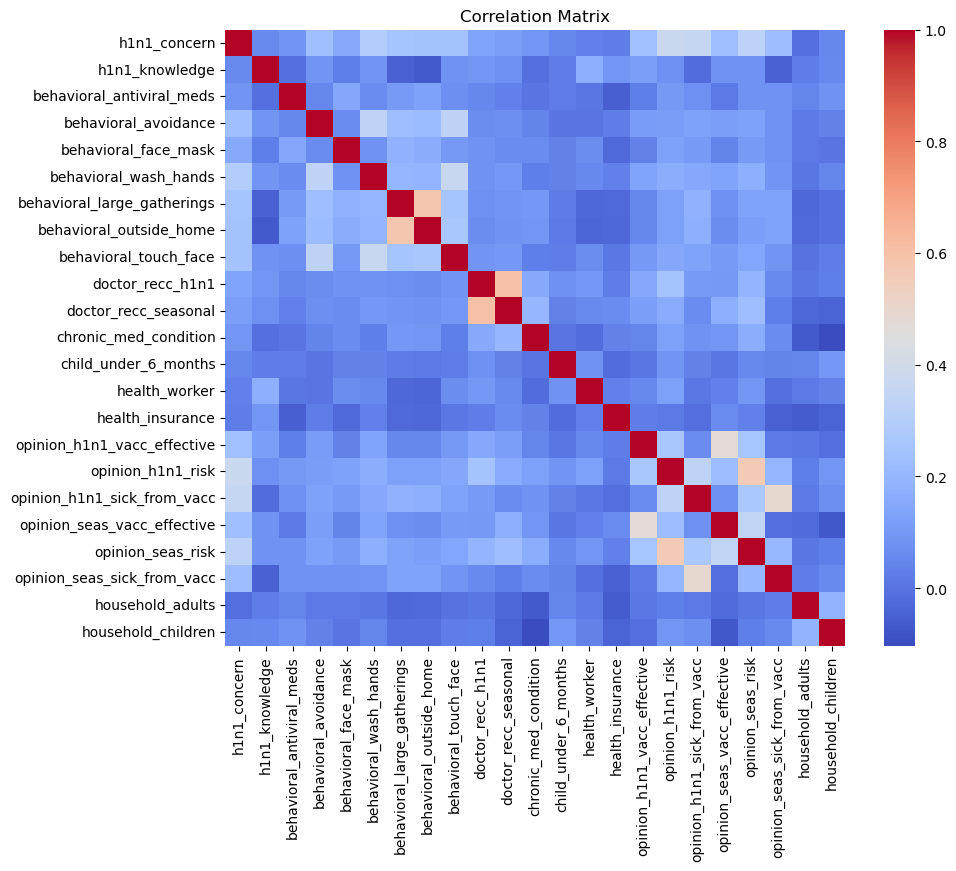

In [110]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")

plt.savefig("../images/plots/correlation_heatmap.png")
plt.show()

Exploratory data analysis reveals several interesting patterns in the dataset. The distribution of the target variable shows that not all individuals received the H1N1 vaccine, which makes this a suitable classification problem. Additionally, factors such as doctor recommendation, age group, and concern about H1N1 appear to be associated with vaccination behavior.

The analysis also shows that several variables contain missing values, which will need to be addressed during the data preparation stage before building machine learning models.

# Data Preparation

In this section, the dataset will be prepared for machine learning modeling. Data preparation involves cleaning the data, handling missing values, removing unnecessary variables, and transforming categorical variables into numerical format. These steps are necessary because most machine learning algorithms require clean, numerical input data.


### 1. Handle Missing Values

Most variables in this dataset are categorical or binary, meaning they represent categories rather than continuous numbers.For categorical data, using the mode preserves the most typical response.



In [65]:
df.fillna(df.mode().iloc[0], inplace=True)

In [66]:
# check again if we still have missing values
df.isnull().sum() 

respondent_id                  0
h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
doctor_recc_seasonal           0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
health_insurance               0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
age_group                      0
education                      0
race                           0
sex                            0
income_poverty                 0
marital_status                 0
rent_or_own                    0
employment_status              0
hhs_geo_re

### 2. Remove Unnecessary Columns

The respondent_id column is removed because it serves only as a unique identifier for survey participants and does not provide predictive information for the machine learning model.

The column seasonal_vaccine was removed from the dataset to prevent potential information leakage. Because individuals who receive the seasonal flu vaccine are more likely to receive the H1N1 vaccine, including this variable could artificially inflate the predictive performance of the model.





In [67]:
df = df.drop(columns=['respondent_id', 'seasonal_vaccine'])

### 3. Encode Categorical Variables

Machine learning algorithms generally require numerical input data. However, several variables in the dataset, such as age_group, education, race, and employment_status, are categorical and cannot be used directly by most models.

One-hot encoding was applied to convert these categorical variables into a numerical format that machine learning models can process. This method creates new binary columns for each category, where a value of 1 indicates the presence of a category and 0 indicates its absence.

Using one-hot encoding ensures that the model does not incorrectly assume an ordinal relationship between categories. For example, categories such as race or marital status do not have a natural numerical order, so one-hot encoding allows the model to treat each category independently.

In [68]:
df_encoded = pd.get_dummies(df, drop_first=True)


df_encoded.head()


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,employment_occupation_qxajmpny,employment_occupation_rcertsgn,employment_occupation_tfqavkke,employment_occupation_ukymxvdu,employment_occupation_uqqtjvyb,employment_occupation_vlluhbov,employment_occupation_xgwztkwe,employment_occupation_xqwwgdyp,employment_occupation_xtkaffoo,employment_occupation_xzmlyyjv
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,False,False,False,False,False,False,True,False,False,False
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False


### 4. Separate Features and Target
Our target variable is h1n1_vaccine

In [69]:
X = df_encoded.drop('h1n1_vaccine', axis=1)
y = df_encoded['h1n1_vaccine']

### 5. Train/Test Split

Split the dataset so we can evaluate the model on unseen data.

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [75]:
df_cleaned = df_encoded

df_cleaned.to_csv("../data/cleaned/h1n1_cleaned.csv", index=False)



# MODELING

#### Check for Class Imbalance

The distribution of the target variable was examined to determine whether the dataset is balanced. 
The results show that a larger proportion of respondents did not receive the H1N1 vaccine compared to those who did.

Class imbalance can affect model performance because a model may achieve high accuracy simply by predicting the majority class. 
Therefore, additional evaluation metrics such as precision, recall, and F1-score will be used to better evaluate model performance.

In [81]:
y_train.value_counts()
print(df['h1n1_vaccine'].value_counts())

print(y_train.value_counts(normalize=True))  #Convert to percentages: 

# 0 = did not receive vaccine
# 1 = received vaccine




h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64
h1n1_vaccine
0    0.787316
1    0.212684
Name: proportion, dtype: float64


## 1. Logistic Regression Model

#### Feature scaling 

Feature scaling was applied because Logistic Regression is sensitive to differences in feature magnitude. Scaling ensures that all variables contribute equally to the model.



In [85]:
# 1 — Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2 — Baseline Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# 3 — Classification Metrics
# accuracy

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)




0.8397603893672781

#### Confusion Matrix

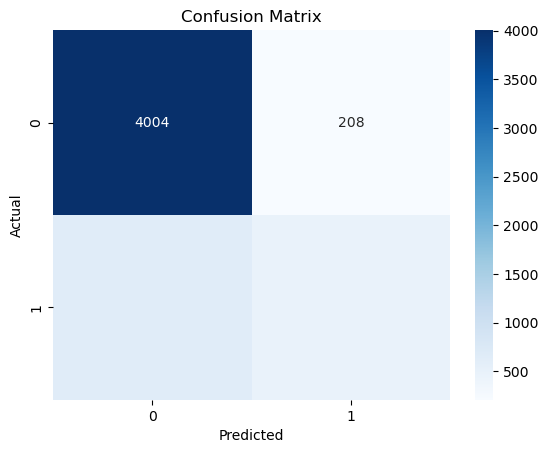

In [113]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../images/plots/confusion_matrix.png")

plt.show()

The confusion matrix shows that the model correctly classified 4004 individuals who did not receive the H1N1 vaccine(True Negative), however 208 individuals were incorrectly predicted to have received the vaccine when they actally did not(False Positive). The model appears to perform well at identifying individuals who did not vaccinate, which suggests that the dataset is imbalanced towards the non-vaccinated class. 

#### Classification Report

In [87]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4212
           1       0.70      0.43      0.53      1130

    accuracy                           0.84      5342
   macro avg       0.78      0.69      0.72      5342
weighted avg       0.83      0.84      0.82      5342



The classification report shows that the model performs well at predicting individuals who did not receive the vaccine. Achieveing a recall of 0.85 and an F1-score of 0.90 for class 0. the model struggles to correctly identify individuals who received the vaccine with a recall of 0.43. this suggests that the model is biased towards the majority class. 

#### ROC Curve & AUC

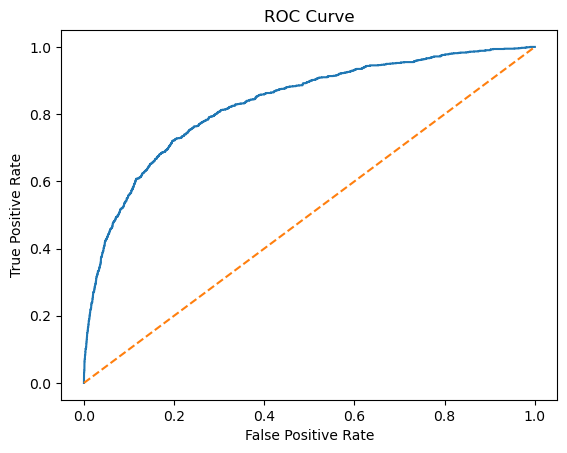

0.8312980611653178

In [114]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.savefig("../images/plots/roc_curve.png")

plt.show()

roc_auc_score(y_test, y_prob)

The ROC curve suggests that the logistic regression model performs substancially better than random guessing. the curve remains well above the diagonal reference line inicating good separation between vaccinated and non vaccinated individuals. The AUC score of approximately 0.83 suggests that the model has good overall discrimination ability. 

Even though the recall for vaccinated individual was low    (0.43), the ROC curve shows that the model does have useful predictive power and adjusting the classification threshold could improve the recall.

#### Cross Validation

In [89]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(log_model, X_train_scaled, y_train, cv=5)

print("Cross Validation Scores:", scores)
print("Average Score:", scores.mean())

Cross Validation Scores: [0.83150012 0.83758484 0.83828692 0.8347765  0.83758484]
Average Score: 0.8359466417037209


Cross validation was performed to evaluate the stability of the logistic regression model across multiple folds of the training dataset. the scores ranged between 0.831 and 0.838, with an average accurecy of approximately 0.836. The consistency of these scores indicates that the model generalizes well and does not exhibit significant overfitting. 

## 2. Decision Tree Model
Decision trees classify observations by splitting the dataset based on feature values. 
These splits are chosen using entropy and information gain.

In [90]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

#### Evaluate Decision Tree

In [91]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4212
           1       0.42      0.43      0.43      1130

    accuracy                           0.75      5342
   macro avg       0.63      0.64      0.63      5342
weighted avg       0.76      0.75      0.75      5342



The decision tree model achieved an overall accuracy of 75%, which is lower than the logistic regression model . this model also performs reasonably well in predicting those who did not receive the vaccine. this also suggests that the model struggles with the imbalance.

#### Hyperparameter Tuning

In [92]:
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth":[3,5,10],
    "min_samples_split":[2,5,10]
}

grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)

grid.fit(X_train, y_train)

grid.best_params_

{'max_depth': 5, 'min_samples_split': 2}

Hyperparameter tuning was performed using GridSearchCV to optimize the Decision Tree model. The search evaluated different combinations of tree depth and minimum samples required for a split. The best performing configuration was a maximum depth of 5 and a minimum sample split of 2. This suggests that a moderately complex tree provides the best balance between learning patterns in the data and avoiding overfitting.

## 3. Random Forest Model

In [103]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_accuracy



              precision    recall  f1-score   support

           0       0.85      0.96      0.90      4212
           1       0.70      0.37      0.48      1130

    accuracy                           0.83      5342
   macro avg       0.78      0.66      0.69      5342
weighted avg       0.82      0.83      0.81      5342



0.8330213403219768

#### Feature Importance

Random Forest allows us to measure which features influence predictions the most.

In [100]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
9,doctor_recc_h1n1,0.092378
16,opinion_h1n1_risk,0.065201
15,opinion_h1n1_vacc_effective,0.056237
19,opinion_seas_risk,0.043625
17,opinion_h1n1_sick_from_vacc,0.031337
0,h1n1_concern,0.030516
20,opinion_seas_sick_from_vacc,0.029080
18,opinion_seas_vacc_effective,0.027614
21,household_adults,0.025268
10,doctor_recc_seasonal,0.024599


#### Visualize Feature Importance

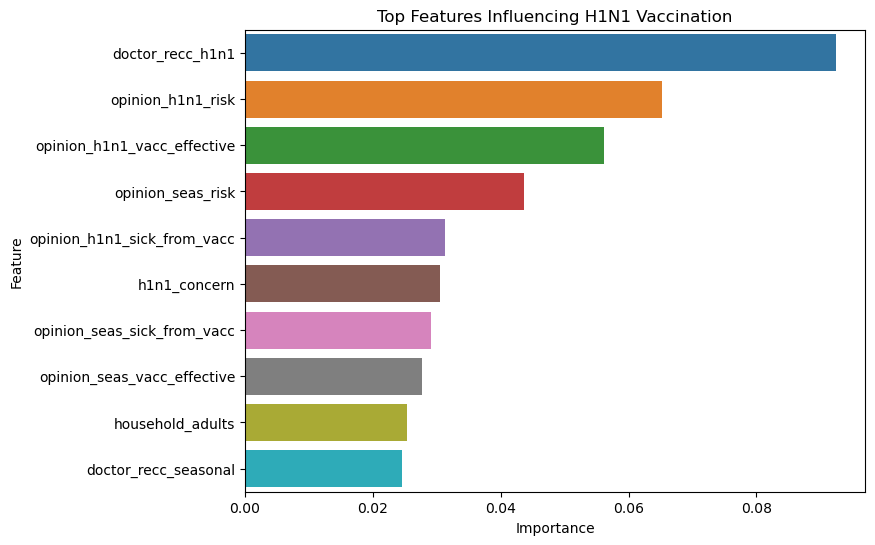

In [ ]:
top_features = importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)


plt.savefig("../images/plots/feature_importance.png")



plt.title("Top Features Influencing H1N1 Vaccination")

plt.savefig("../images/plots/roc_curve.png")

plt.show()

The feature importance analysis suggests that variables such as doctor recommendation, concern about H1N1, and healthcare worker status play a significant role in predicting vaccination behavior.

These findings align with expectations because individuals who receive medical advice or perceive higher risk are more likely to choose vaccination.

## Model Comparison

In [102]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, tree_pred),
        rf_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.839760
1,Decision Tree,0.753463
2,Random Forest,0.833021




Three classification models were evaluated in this project: Logistic Regression, Decision Tree, and Random Forest. Each model has different strengths and weaknesses in terms of bias, variance, and predictive performance.

Logistic Regression demonstrated stable performance across cross-validation folds and produced consistent predictions on the test dataset. Because Logistic Regression is a relatively simple model with linear assumptions, it tends to have higher bias but lower variance, which often helps prevent overfitting.

The Decision Tree model was able to capture more complex relationships in the data due to its non-linear structure. However, decision trees are prone to overfitting, which can lead to higher variance. Even after applying hyperparameter tuning to limit tree depth and control model complexity, the Decision Tree still showed slightly lower performance compared to Logistic Regression.

The Random Forest model, which is an ensemble method built from multiple decision trees, helped reduce the overfitting problem seen in a single decision tree. By averaging predictions from many trees, Random Forest achieved more stable predictions and improved generalization compared to the individual Decision Tree model.

Overall, the Random Forest model provided strong predictive performance while maintaining better control over variance than a single decision tree. Logistic Regression remained competitive due to its stability and interpretability, while the Decision Tree served as a useful benchmark for comparison.

# Final Model Selection

Based on the evaluation of multiple models, Logistic Regression was selected as the final model for this project.

Although Random Forest also performed well, Logistic Regression achieved the highest accuracy and demonstrated strong generalization during cross-validation. In addition, Logistic Regression provides greater interpretability, allowing public health stakeholders to better understand the factors influencing vaccination behavior.

Because interpretability and reliable performance are important for public health decision-making, Logistic Regression was considered the most appropriate model for predicting H1N1 vaccination uptake.

# Key Insights from the Analysis



The analysis identified several important factors that influence whether individuals receive the H1N1 vaccine.

First, doctor recommendation emerged as one of the strongest predictors of vaccination behavior. Individuals who were advised by a healthcare professional to receive the vaccine were significantly more likely to do so. This suggests that medical professionals play a critical role in encouraging vaccination.

Second, perceived risk and concern about the H1N1 virus were strongly associated with vaccination decisions. Respondents who reported higher levels of concern about the virus were more likely to receive the vaccine, indicating that risk perception influences preventive health behavior.

Third, occupation also played an important role. Healthcare workers were more likely to be vaccinated, likely due to increased exposure to infectious diseases and stronger awareness of vaccination benefits.

Additionally, demographic factors such as age group showed some influence on vaccination behavior, with older individuals tending to have higher vaccination rates. This may reflect greater awareness of health risks among older populations.

Overall, the findings highlight the importance of medical advice, risk perception, and occupational exposure in shaping vaccination decisions.

## Recommendations

Based on the findings of this analysis, several recommendations can be made to improve vaccination uptake.

- First, public health organizations should encourage healthcare providers to actively recommend vaccines to patients. The analysis showed that doctor recommendation is one of the strongest predictors of vaccination behavior. Increasing the frequency and visibility of these recommendations could significantly improve vaccination rates.

- Second, public health campaigns should focus on increasing public awareness of the risks associated with influenza. Individuals who expressed greater concern about the H1N1 virus were more likely to receive the vaccine, suggesting that improving risk awareness may encourage preventive health behaviors.

- Third, targeted outreach programs could be developed for groups with lower vaccination rates. Educational campaigns, community outreach, and accessible vaccination programs could help increase vaccination uptake among populations that may not perceive themselves as at risk.

- Finally, workplace vaccination initiatives, especially in healthcare settings, could be expanded to ensure that individuals who are more likely to be exposed to infectious diseases receive appropriate protection.

# Limitations

Although this analysis provides useful insights into factors influencing H1N1 vaccination behavior, several limitations should be considered.

- First, the dataset is based on survey responses, which may contain self-reported information. Respondents may misreport their behaviors or perceptions, which could affect the accuracy of the data.

- Second, the data was collected during the 2009 H1N1 pandemic. Vaccination behaviors and attitudes may have changed over time, meaning that the results may not fully represent current vaccination trends.

- Third, some variables in the dataset contained missing values that required imputation during the data preparation stage. While appropriate methods were used to handle missing data, imputation can introduce some uncertainty into the analysis.

- Additionally, the model relies only on the available survey variables, which may not fully capture all factors influencing vaccination decisions. External factors such as accessibility, misinformation, or cultural attitudes may also play a role but are not included in the dataset

- Finally, while machine learning models can identify patterns in the data, they do not necessarily establish causal relationships. The models can predict vaccination behavior but cannot determine the exact reasons why individuals choose to receive or refuse vaccines.

# Future Improvements

Several opportunities exist to improve this analysis in future work.

First, additional machine learning models such as Gradient Boosting or XGBoost could be explored to determine whether more advanced ensemble methods can improve predictive performance.

Second, feature engineering techniques could be applied to create new variables that better capture relationships within the data. For example, combining demographic and behavioral variables may reveal more complex patterns influencing vaccination decisions.

Third, future studies could incorporate more recent vaccination datasets to examine whether the factors influencing vaccination behavior have changed over time.

Finally, incorporating external data sources such as geographic information, healthcare access, or socioeconomic indicators could provide deeper insights into vaccination behavior and improve the predictive power of the models.

# Conclusion

This project aimed to predict whether individuals received the H1N1 flu vaccine using machine learning models trained on survey data from the National 2009 H1N1 Flu Survey. The analysis explored demographic characteristics, health behaviors, and perceptions related to vaccination.

Several machine learning models were developed and evaluated, including Logistic Regression, Decision Tree, and Random Forest. Among these models, Random Forest provided strong predictive performance while maintaining good generalization compared to a single decision tree.

The analysis identified several key factors influencing vaccination behavior. Doctor recommendation, concern about the H1N1 virus, and healthcare worker status were among the most important predictors of whether individuals received the vaccine.

These findings suggest that public health efforts focusing on increasing medical recommendations and improving public awareness of influenza risks could help improve vaccination uptake. By understanding the factors that influence vaccination decisions, policymakers and healthcare providers can design more effective vaccination campaigns and outreach strategies.